## Block-1: Libraries and Mounting the drive

In [ ]:
# Importing Libraries
import os
import torch
from torchvision import datasets, transforms

In [ ]:
# Mount Google Drive to access CUB-200-2011 dataset

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Block-2: Verify CUB metadata and official splits

In [ ]:
# Block 2: Verify CUB-200-2011 structure and official splits

import os
import pandas as pd

data_root = "/content/drive/MyDrive/CUB_200_2011"

# Required CUB files
required_files = [
    "images.txt",
    "image_class_labels.txt",
    "train_test_split.txt",
    "classes.txt",
    "images"
]

print("Checking CUB directory structure...\n")
for f in required_files:
    path = os.path.join(data_root, f)
    print(f, "->", "FOUND" if os.path.exists(path) else "MISSING")

# Load metadata
images_df = pd.read_csv(
    os.path.join(data_root, "images.txt"),
    sep=" ",
    names=["img_id", "filepath"]
)

labels_df = pd.read_csv(
    os.path.join(data_root, "image_class_labels.txt"),
    sep=" ",
    names=["img_id", "class_id"]
)

split_df = pd.read_csv(
    os.path.join(data_root, "train_test_split.txt"),
    sep=" ",
    names=["img_id", "is_train"]
)

# Merge all metadata
cub_df = images_df.merge(labels_df, on="img_id").merge(split_df, on="img_id")

# Basic verification
num_train = (cub_df["is_train"] == 1).sum()
num_test = (cub_df["is_train"] == 0).sum()
num_classes = cub_df["class_id"].nunique()

print("\nDataset verification:")
print("Total images:", len(cub_df))
print("Training images:", num_train)
print("Test images:", num_test)
print("Number of classes:", num_classes)

Checking CUB directory structure...

images.txt -> FOUND
image_class_labels.txt -> FOUND
train_test_split.txt -> FOUND
classes.txt -> FOUND
images -> FOUND

Dataset verification:
Total images: 11788
Training images: 5994
Test images: 5794
Number of classes: 200


## Block-3: Custom CUBDataset (official split, ImageNet preprocessing)

In [ ]:
# Custom CUB Dataset using official splits

from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transform_test = transform_train


class CUBDataset(Dataset):
    def __init__(self, dataframe, data_root, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.data_root, "images", row["filepath"])
        image = Image.open(img_path).convert("RGB")

        label = row["class_id"] - 1  # convert 1–200 → 0–199

        if self.transform:
            image = self.transform(image)

        return image, label

Create train & test datasets

In [ ]:
# Split using official CUB split
train_df = cub_df[cub_df["is_train"] == 1]
test_df  = cub_df[cub_df["is_train"] == 0]

train_dataset = CUBDataset(train_df, data_root, transform=transform_train)
test_dataset  = CUBDataset(test_df, data_root, transform=transform_test)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 5994
Test samples: 5794


## Block-4: DataLoaders

In [ ]:
# DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0   # important for Drive
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

## Block-5: Data Exploration

In [ ]:
# Basic CUB dataset exploration (structure-aligned with CIFAR)
from collections import Counter

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

# Number of classes
num_classes = len(cub_df["class_id"].unique())
print("Number of classes:", num_classes)

# Inspect one training sample

sample_img, sample_label = train_dataset[0]

print("Single image shape (C, H, W):", sample_img.shape)
print("Sample label index:", sample_label)


# Pixel value range check (after ImageNet normalization)

print("Pixel min:", sample_img.min().item())
print("Pixel max:", sample_img.max().item())
# Images per class (training split)



train_labels = train_df["class_id"].values
class_counts = Counter(train_labels)

counts = list(class_counts.values())

print("Min images per class:", min(counts))
print("Max images per class:", max(counts))


Number of training samples: 5994
Number of test samples: 5794
Number of classes: 200
Single image shape (C, H, W): torch.Size([3, 224, 224])
Sample label index: 0
Pixel min: -2.1007792949676514
Pixel max: 2.5877127647399902
Min images per class: 29
Max images per class: 30


In [ ]:
# Images per class (training set) — CUB-200 (CIFAR-style)

from collections import Counter
import pandas as pd
import os

# Load class names (1-indexed in file)
classes_df = pd.read_csv(
    os.path.join(data_root, "classes.txt"),
    sep=" ",
    names=["class_id", "class_name"]
)

# Count training samples per class_id
class_counts = Counter(train_df["class_id"])

print("\nImages per class (training set):")
for _, row in classes_df.iterrows():
    cid = row["class_id"]
    cname = row["class_name"]
    print(f"{cname}: {class_counts[cid]}")


Images per class (training set):
001.Black_footed_Albatross: 30
002.Laysan_Albatross: 30
003.Sooty_Albatross: 30
004.Groove_billed_Ani: 30
005.Crested_Auklet: 30
006.Least_Auklet: 30
007.Parakeet_Auklet: 30
008.Rhinoceros_Auklet: 30
009.Brewer_Blackbird: 30
010.Red_winged_Blackbird: 30
011.Rusty_Blackbird: 30
012.Yellow_headed_Blackbird: 30
013.Bobolink: 30
014.Indigo_Bunting: 30
015.Lazuli_Bunting: 30
016.Painted_Bunting: 30
017.Cardinal: 30
018.Spotted_Catbird: 30
019.Gray_Catbird: 30
020.Yellow_breasted_Chat: 30
021.Eastern_Towhee: 30
022.Chuck_will_Widow: 30
023.Brandt_Cormorant: 30
024.Red_faced_Cormorant: 30
025.Pelagic_Cormorant: 30
026.Bronzed_Cowbird: 30
027.Shiny_Cowbird: 30
028.Brown_Creeper: 30
029.American_Crow: 30
030.Fish_Crow: 30
031.Black_billed_Cuckoo: 30
032.Mangrove_Cuckoo: 30
033.Yellow_billed_Cuckoo: 30
034.Gray_crowned_Rosy_Finch: 30
035.Purple_Finch: 30
036.Northern_Flicker: 30
037.Acadian_Flycatcher: 30
038.Great_Crested_Flycatcher: 30
039.Least_Flycatcher: 30

In [ ]:
# Channel-wise mean and std (CUB training set)

import torch
from torch.utils.data import DataLoader


loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

mean = torch.zeros(3)
std = torch.zeros(3)
n = 0

for imgs, _ in loader:
    b, c, h, w = imgs.shape
    imgs = imgs.view(b, c, -1)
    mean += imgs.mean(2).sum(0)
    std += imgs.std(2).sum(0)
    n += b

mean /= n
std /= n

print("Channel-wise mean:", mean)
print("Channel-wise std :", std)

Channel-wise mean: tensor([0.0027, 0.1939, 0.1173])
Channel-wise std : tensor([0.7614, 0.7753, 0.8241])


In [ ]:
# Pixel statistics over one batch

imgs, _ = next(iter(train_loader))

print("Batch pixel min:", imgs.min().item())
print("Batch pixel max:", imgs.max().item())
print("Batch mean:", imgs.mean().item())
print("Batch std :", imgs.std().item())

Batch pixel min: -2.1179039478302
Batch pixel max: 2.640000104904175
Batch mean: 0.13746055960655212
Batch std : 0.9712355136871338


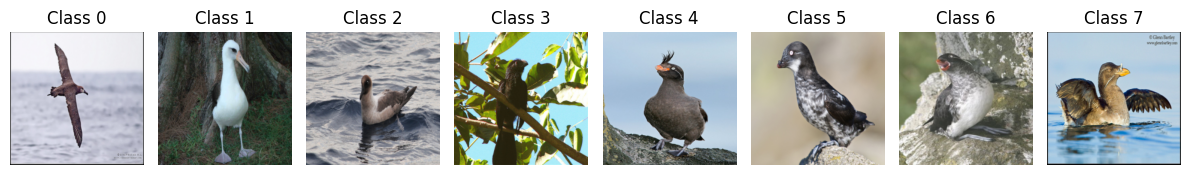

In [ ]:
# Visualize one sample image from first N classes

import matplotlib.pyplot as plt

N = 8  # keep UI sane
class_seen = set()
samples = []

for img, label in train_dataset:
    if label not in class_seen:
        samples.append((img, label))
        class_seen.add(label)
    if len(samples) == N:
        break

plt.figure(figsize=(12, 4))
for i, (img, label) in enumerate(samples):
    plt.subplot(1, N, i + 1)

    # unnormalize for visualization
    img_vis = img.clone()
    img_vis = img_vis * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_vis = img_vis + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)

    img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()
    plt.imshow(img_vis)
    plt.title(f"Class {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Dataset vs DataLoader consistency check

img_ds, lbl_ds = train_dataset[0]
img_dl, lbl_dl = next(iter(train_loader))

print("Dataset image shape :", img_ds.shape)
print("Loader batch shape  :", img_dl.shape)
print("Dataset label type  :", type(lbl_ds))
print("Loader label dtype  :", lbl_dl.dtype)

Dataset image shape : torch.Size([3, 224, 224])
Loader batch shape  : torch.Size([64, 3, 224, 224])
Dataset label type  : <class 'numpy.int64'>
Loader label dtype  : torch.int64


## Block-6: Load pretrained EfficientNet-B0 for CUB-200

Block-6.1: Load ImageNet-pretrained EfficientNet-B0

In [ ]:
# Load EfficientNet-B0 for CUB-200

import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ImageNet-pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# Replace classifier for 200 CUB classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 200)

model = model.to(device)
model.eval()

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Block-6.2: Forward-pass sanity check

In [ ]:
# Forward pass sanity check

model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input batch shape :", images.shape)     # [B, 3, 224, 224]
print("Output logits shape:", outputs.shape)   # [B, 200]
print("Sample predicted classes:", outputs.argmax(dim=1)[:10])
print("Sample true classes     :", labels[:10])

Input batch shape : torch.Size([64, 3, 224, 224])
Output logits shape: torch.Size([64, 200])
Sample predicted classes: tensor([137, 172, 158,  18,  16, 162, 198, 102,  91, 130], device='cuda:0')
Sample true classes     : tensor([183, 185, 186,  55,  36,   3, 179,  73, 103,  19], device='cuda:0')


## Block-7: Training setup

In [ ]:
# Training setup (CIFAR-style, CUB-scaled)

import torch.optim as optim
import torch.nn as nn

epochs = 10          # keep same as CIFAR for structural parity
lr = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=lr
)

# Tracking (used later for plots)
train_losses = []
train_accuracies = []
test_accuracies = []

## Block-8: Training loop

In [ ]:
# Training loop (CIFAR-style)

model.train()

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_loss = running_loss
    epoch_acc = 100.0 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_acc:.2f}%"
    )

Epoch [1/10] | Loss: 327.2402 | Train Acc: 24.44%
Epoch [2/10] | Loss: 124.2984 | Train Acc: 63.08%
Epoch [3/10] | Loss: 61.6724 | Train Acc: 81.10%
Epoch [4/10] | Loss: 33.4192 | Train Acc: 89.97%
Epoch [5/10] | Loss: 19.6317 | Train Acc: 94.73%
Epoch [6/10] | Loss: 13.2362 | Train Acc: 96.50%
Epoch [7/10] | Loss: 11.7008 | Train Acc: 96.65%
Epoch [8/10] | Loss: 9.5617 | Train Acc: 97.65%
Epoch [9/10] | Loss: 9.6862 | Train Acc: 97.11%
Epoch [10/10] | Loss: 9.7650 | Train Acc: 97.15%


## Block-9: Testing & prediction collection

In [ ]:
model.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        if i % 10 == 0:
            print(f"Processing batch {i}")

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100.0 * correct / total
test_accuracies.append(test_acc)

print(f"Test Accuracy: {test_acc:.2f}%")

Processing batch 0
Processing batch 10
Processing batch 20
Processing batch 30
Processing batch 40
Processing batch 50
Processing batch 60
Processing batch 70
Processing batch 80
Processing batch 90
Test Accuracy: 66.52%


## Block-10: Training & Testing Curves

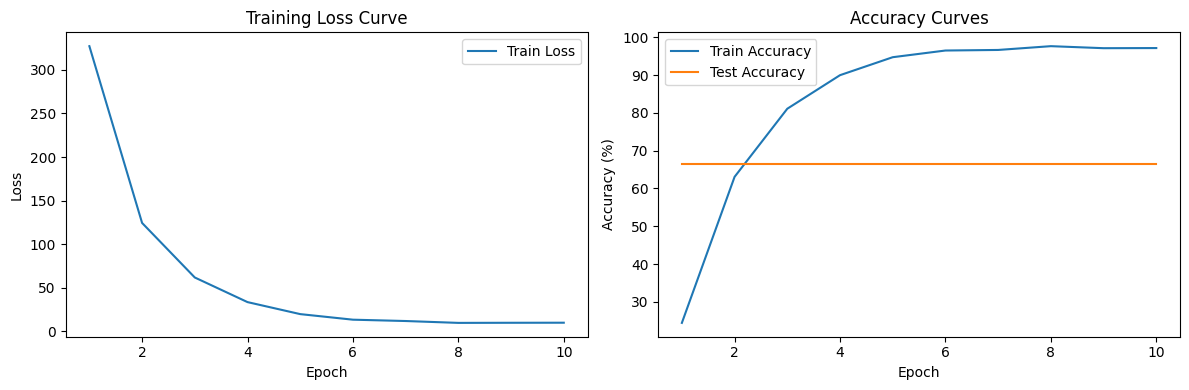

In [ ]:
# Training & Testing Curves

import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

# Training Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, test_accuracies * epochs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

## Block-11: Confusion Matrix and Class Prediction Visualization

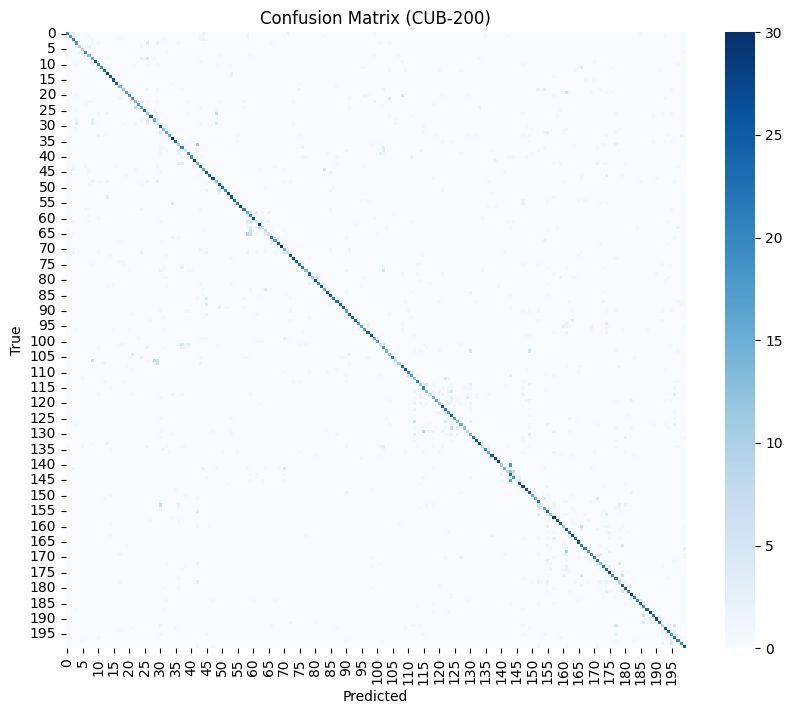

In [ ]:
# Block-11.1: Confusion Matrix (CIFAR-style)

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CUB-200)")
plt.show()

In [ ]:
# Block-11.2: Sample Correct & Incorrect Predictions (CIFAR-style)

correct_samples = []
incorrect_samples = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = outputs.max(1)

        for i in range(len(images)):
            if preds[i] == labels[i] and len(correct_samples) < 5:
                correct_samples.append(
                    (images[i].cpu(), labels[i].item(), preds[i].item())
                )
            elif preds[i] != labels[i] and len(incorrect_samples) < 5:
                incorrect_samples.append(
                    (images[i].cpu(), labels[i].item(), preds[i].item())
                )

        if len(correct_samples) == 5 and len(incorrect_samples) == 5:
            break

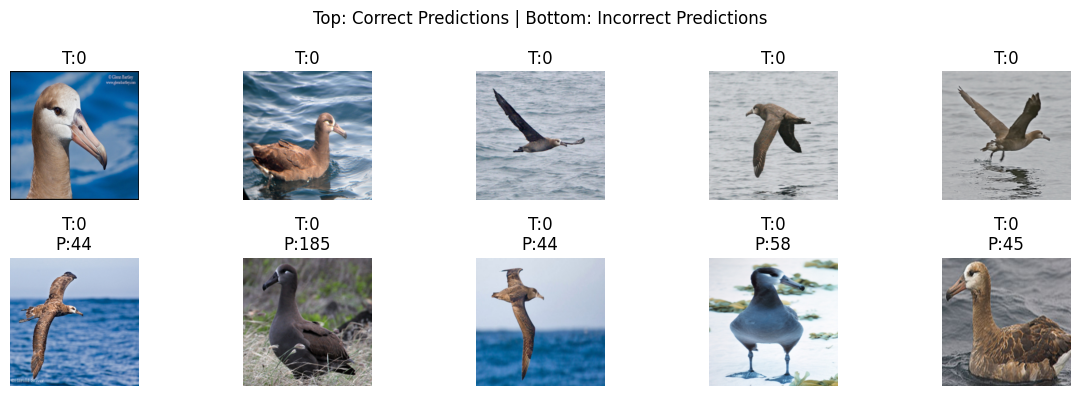

In [ ]:
# Visualize correct vs incorrect predictions

plt.figure(figsize=(12, 4))

# Correct predictions (top row)
for i, (img, true, pred) in enumerate(correct_samples):
    plt.subplot(2, 5, i + 1)

    img_vis = img.clone()
    img_vis = img_vis * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_vis = img_vis + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()

    plt.imshow(img_vis)
    plt.title(f"T:{true}")
    plt.axis("off")

# Incorrect predictions (bottom row)
for i, (img, true, pred) in enumerate(incorrect_samples):
    plt.subplot(2, 5, i + 6)

    img_vis = img.clone()
    img_vis = img_vis * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_vis = img_vis + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()

    plt.imshow(img_vis)
    plt.title(f"T:{true}\nP:{pred}")
    plt.axis("off")

plt.suptitle("Top: Correct Predictions | Bottom: Incorrect Predictions")
plt.tight_layout()
plt.show()


## Block-12: Freez and Save the Model

In [ ]:
# Freeze the trained model

for param in model.parameters():
    param.requires_grad = False

print("Model frozen.")

Model frozen.


In [ ]:
# Save and download the trained CUB-200 EfficientNet-B0 model

import torch

model_path = "EfficientNet-B0_cub200_frozen.pth"

# Save model weights
torch.save(model.state_dict(), model_path)
print(f"Model saved locally as: {model_path}")

# Download to local machine
from google.colab import files
files.download(model_path)

Model saved locally as: EfficientNet-B0_cub200_frozen.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>